In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
class SearchState(TypedDict):
    user_profile : dict
    queries : list[str]
    raw_jobs : list[dict]
    scored_jobs: list[dict]

In [3]:
def User_input(state: SearchState):
    name = input("Enter your name: ")
    skills_input = input("Enter skills (comma separated): ")
    preferred_role = input("Enter preferred role: ")
    location = input("Enter preferred location: ")

    skills = [skill.strip() for skill in skills_input.split(",")]

    state["user_profile"] = {
        "name": name,
        "skills": skills,
        "preferred_role": preferred_role,
        "location": location
    }

    return state


def Query_builder(state: SearchState):
    skills = state["user_profile"]["skills"]
    role = state["user_profile"]["preferred_role"]

    queries = [role]

    for skill in skills:
        queries.append(f"{role} {skill}")

    state["queries"] = list(set(queries))

    return state


In [ ]:
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options

def Linkedin_job_scrapper(state):

    location = state["user_profile"]["location"]
    queries = state["queries"]

    options = Options()
    options.add_argument("--start-maximized")

    driver = webdriver.Chrome(options=options)

    all_jobs = []

    for query in queries:
        query_encoded = query.replace(" ", "%20")
        location_encoded = location.replace(" ", "%20")

        url = f"https://www.linkedin.com/jobs/search/?keywords={query_encoded}&location={location_encoded}&f_TPR=r604800"
        
        driver.get(url)
        time.sleep(5)  #wait for page load

        #Small scroll to load more jobs
        driver.execute_script("window.scrollTo(0, 800);")
        time.sleep(2)

        job_cards = driver.find_elements(By.CLASS_NAME, "base-card")

        job_cards = job_cards[:20]

        for card in job_cards:
            try:
                title = card.find_element(By.CLASS_NAME, "base-search-card__title").text
                company = card.find_element(By.CLASS_NAME, "base-search-card__subtitle").text
                loc = card.find_element(By.CLASS_NAME, "job-search-card__location").text
                link = card.find_element(By.TAG_NAME, "a").get_attribute("href")

                #Click card to load description panel
                card.click()
                time.sleep(2)

                # Extract description
                try:
                    description = driver.find_element(
                        By.CLASS_NAME, "show-more-less-html__markup"
                    ).text
                except:
                    description = ""

                all_jobs.append({
                    "title": title,
                    "company": company,
                    "location": loc,
                    "link": link,
                    "description": description
                })

            except:
                continue

    driver.quit()

    state["raw_jobs"] = all_jobs
    return state


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load model once
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def match_scoring_node(state):

    raw_jobs = state["raw_jobs"]
    user_profile = state["user_profile"]
    user_text = " ".join(user_profile["skills"])

    user_vector = embedding_model.encode([user_text])
    scored_jobs = []
    for job in raw_jobs:
        job_text = job.get("description", "")
        if not job_text.strip():
            job_text = job["title"] + " " + job["company"] + " " + job["location"]

        job_vector = embedding_model.encode([job_text])
        score = cosine_similarity(user_vector, job_vector)[0][0]

        job_with_score = job.copy()
        job_with_score["score"] = float(score)

        scored_jobs.append(job_with_score)

    scored_jobs = sorted(scored_jobs, key=lambda x: x["score"], reverse=True)

    state["scored_jobs"] = scored_jobs
    return state


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 757.94it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
graph = StateGraph(SearchState)

graph.add_node('User_input',User_input)
graph.add_node('Query_builder',Query_builder)
graph.add_node('Linkedin_job_scrapper',Linkedin_job_scrapper)
graph.add_node('match_scoring_node',match_scoring_node)

graph.add_edge(START,'User_input')
graph.add_edge('User_input','Query_builder')
graph.add_edge('Query_builder','Linkedin_job_scrapper')
graph.add_edge('Linkedin_job_scrapper','match_scoring_node')
graph.add_edge('match_scoring_node',END)

workflow = graph.compile()

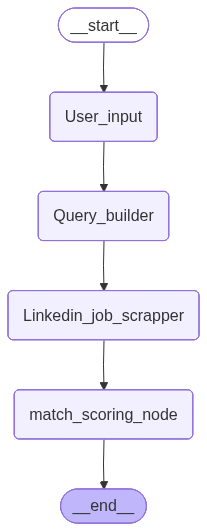

In [9]:
workflow

In [10]:
initial_state = {
    "user_profile": {},
    "queries": [],
    "raw_jobs": []
}
final_state = workflow.invoke(initial_state)

In [11]:
print("\nJobs Found:\n")
for job in final_state["raw_jobs"][:10]:
    print(job)
    print("*"*100)


Jobs Found:

{'title': 'AI/ML Engineer', 'company': 'Xerox', 'location': '', 'link': 'https://in.linkedin.com/jobs/view/ai-ml-engineer-at-xerox-4362592569?position=8&pageNum=0&refId=gY3m0pgNwdHVOZNImJIJ2A%3D%3D&trackingId=2ycgm4HzyHDnLxUDK%2FbciQ%3D%3D', 'description': 'About Xerox Holdings Corporation\n\nAt Xerox, we make work, work! For more than 100 years, Xerox has continually redefined the workplace experience. From the office to industrial environments, our differentiated business and technology offerings and financial services are essential workplace technology solutions that drive success for our clients and within our culture. Learn more at www.xerox.com and explore our commitment to diversity, inclusion and belonging.\n\nWe are on a mission to drive innovation and transformation through the use of Artificial Intelligence (AI) and Machine Learning (ML) across the organization. We are looking for experienced professionals who bring deep technical expertise, a problem-solving m

In [12]:
print("\nTop Matched Jobs:\n")

for job in final_state["scored_jobs"][:5]:
    print(f"Title: {job['title']}")
    print(f"Company: {job['company']}")
    print(f"Location: {job['location']}")
    print(f"Score: {job['score']:.4f}")
    print(f"Link: {job['link']}")
    print("-" * 100)
    print(" ")



Top Matched Jobs:

Title: Software Engineer (Python, AI/ML) ID47296
Company: AgileEngine
Location: Kolkata, West Bengal, India
Score: 0.4147
Link: https://in.linkedin.com/jobs/view/software-engineer-python-ai-ml-id47296-at-agileengine-4371537548?position=11&pageNum=0&refId=n94wIOcM2lGFvkfu7Btvmw%3D%3D&trackingId=M3Nqu1vQpH45liTJBDowsw%3D%3D
----------------------------------------------------------------------------------------------------
 
Title: Remote ML Engineer - 60735
Company: Turing
Location: Kolkata, West Bengal, India
Score: 0.3378
Link: https://in.linkedin.com/jobs/view/remote-ml-engineer-60735-at-turing-4372100311?position=17&pageNum=0&refId=zFnr%2BNPSv2V1PBOXNNXXIQ%3D%3D&trackingId=2tOucZr%2F7U%2F0ObW24gp%2FFQ%3D%3D
----------------------------------------------------------------------------------------------------
 
Title: Remote ML Engineer - 60735
Company: Turing
Location: Kolkata, West Bengal, India
Score: 0.3378
Link: https://in.linkedin.com/jobs/view/remote-ml-engin